# 08 - Model Comparison and Evaluation

Pull all logged runs from `results/model_comparison.csv`, identify the best model, and produce comparison figures (MAE, RMSE, R², MAPE, training time) across Linear Regression, LSTM, TCN, and the TCN-LSTM hybrid.

Figures are saved to `results/figures/`.

**Note:** `model_comparison.csv` only stores metrics, not the hyperparameters (`window_size`, `hidden_size`, etc.) used to produce them.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

results_path = Path("../results/model_comparison.csv")
figures_dir = Path("../results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

model_order = ["linear_regression", "lstm", "tcn", "tcn_lstm_hybrid"]

In [3]:
if not results_path.exists():
    alt_results_path = Path.cwd() / "results" / results_path.name
    if alt_results_path.exists():
        results_path = alt_results_path
    else:
        raise FileNotFoundError(
            f"Could not find {results_path}. Checked {results_path} and {alt_results_path}"
        )

results_df = pd.read_csv(results_path)

# keep only the most recent logged run per model/split, in case a notebook was rerun
results_df = results_df.drop_duplicates(subset=["model_name", "split"], keep="last").reset_index(drop=True)
results_df

,model_name,split,mae,rmse,r2,mape,training_time_sec
0,linear_regression,validation,1.295229,1.596696,0.306578,34.902911,0.001335
1,linear_regression,test,1.793972,2.177868,0.593271,99.852282,0.001335
2,lstm,validation,1.229843,1.618578,0.287442,32.174500,1.505211
3,lstm,test,1.428457,1.928082,0.681219,92.963594,1.505211
4,tcn,validation,1.220287,1.547769,0.348424,33.484685,3.668712
5,tcn,test,1.096119,1.450039,0.819698,78.259734,3.668712
6,tcn_lstm_hybrid,validation,1.266178,1.698141,0.215668,33.352908,4.882465
7,tcn_lstm_hybrid,test,1.505896,1.896227,0.691665,107.541433,4.882465


In [4]:
val_df = results_df[results_df["split"] == "validation"].set_index("model_name").reindex(model_order)
test_df = results_df[results_df["split"] == "test"].set_index("model_name").reindex(model_order)

test_df

,split,mae,rmse,r2,mape,training_time_sec
model_name,,,,,,
linear_regression,test,1.793972,2.177868,0.593271,99.852282,0.001335
lstm,test,1.428457,1.928082,0.681219,92.963594,1.505211
tcn,test,1.096119,1.450039,0.819698,78.259734,3.668712
tcn_lstm_hybrid,test,1.505896,1.896227,0.691665,107.541433,4.882465


In [5]:
best_model_name = test_df["rmse"].idxmin()
best_model_row = test_df.loc[best_model_name]

print(f"Best model on test rmse: {best_model_name}")
best_model_row

Best model on test rmse: tcn


split                     test
mae                   1.096119
rmse                  1.450039
r2                    0.819698
mape                 78.259734
training_time_sec     3.668712
Name: tcn, dtype: object

In [6]:
comparison_table = results_df.pivot(index="model_name", columns="split", values=["mae", "rmse", "r2", "mape", "training_time_sec"])
comparison_table = comparison_table.reindex(model_order)
comparison_table.to_csv(figures_dir.parent / "comparison_table.csv")
comparison_table

mae                 rmse                   r2  \
split                  test validation      test validation      test   
model_name                                                              
linear_regression  1.793972   1.295229  2.177868   1.596696  0.593271   
lstm               1.428457   1.229843  1.928082   1.618578  0.681219   
tcn                1.096119   1.220287  1.450039   1.547769  0.819698   
tcn_lstm_hybrid    1.505896   1.266178  1.896227   1.698141  0.691665   

                                    mape            training_time_sec  \
split             validation        test validation              test   
model_name                                                              
linear_regression   0.306578   99.852282  34.902911          0.001335   
lstm                0.287442   92.963594  32.174500          1.505211   
tcn                 0.348424   78.259734  33.484685          3.668712   
tcn_lstm_hybrid     0.215668  107.541433  33.352908          4.882465   

                              
split             validation  
model_name                    
linear_regression   0.001335  
lstm                1.505211  
tcn                 3.668712  
tcn_lstm_hybrid     4.882465

In [7]:
def plot_metric_comparison(metric, ylabel, filename):
    fig, ax = plt.subplots(figsize=(7, 4))
    x = range(len(model_order))
    width = 0.35

    ax.bar([i - width / 2 for i in x], val_df[metric], width, label="validation")
    ax.bar([i + width / 2 for i in x], test_df[metric], width, label="test")

    ax.set_xticks(list(x))
    ax.set_xticklabels(model_order, rotation=15)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by model")

    fig.tight_layout()
    fig.savefig(figures_dir / filename, dpi=600)
    plt.show()

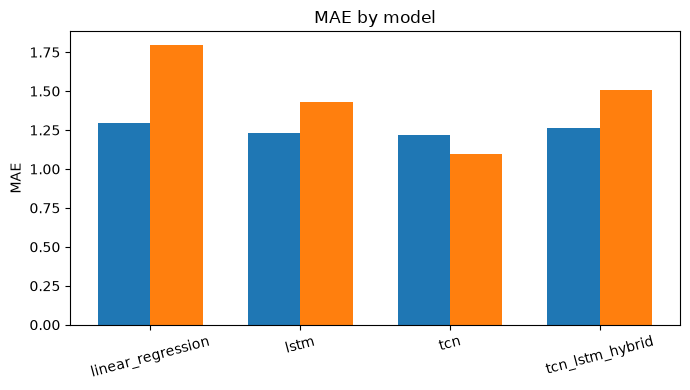

In [8]:
plot_metric_comparison("mae", "MAE", "mae_comparison.png")

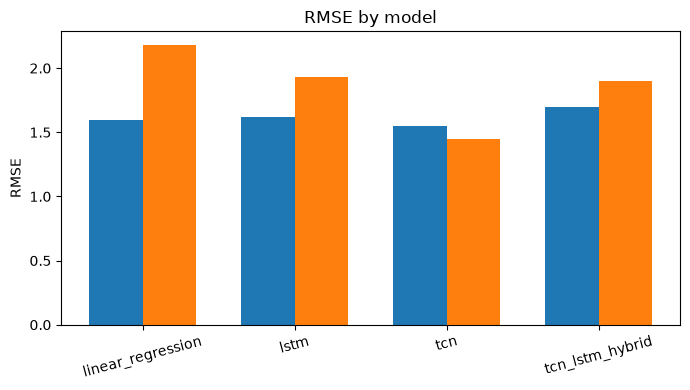

In [9]:
plot_metric_comparison("rmse", "RMSE", "rmse_comparison.png")

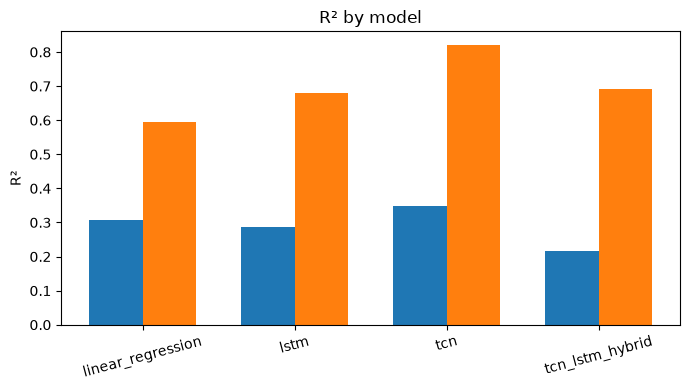

In [10]:
plot_metric_comparison("r2", "R²", "r2_comparison.png")

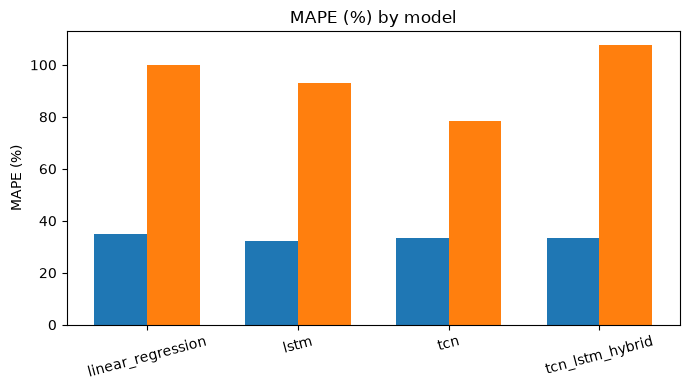

In [11]:
plot_metric_comparison("mape", "MAPE (%)", "mape_comparison.png")

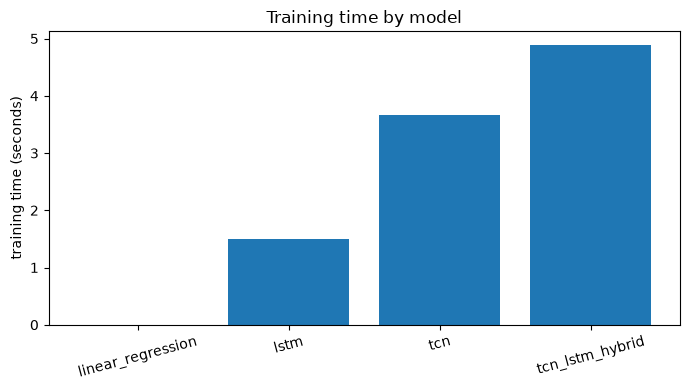

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(model_order, test_df["training_time_sec"])
ax.set_ylabel("training time (seconds)")
ax.set_title("Training time by model")
plt.xticks(rotation=15)

fig.tight_layout()
fig.savefig(figures_dir / "training_time_comparison.png", dpi=600)
plt.show()

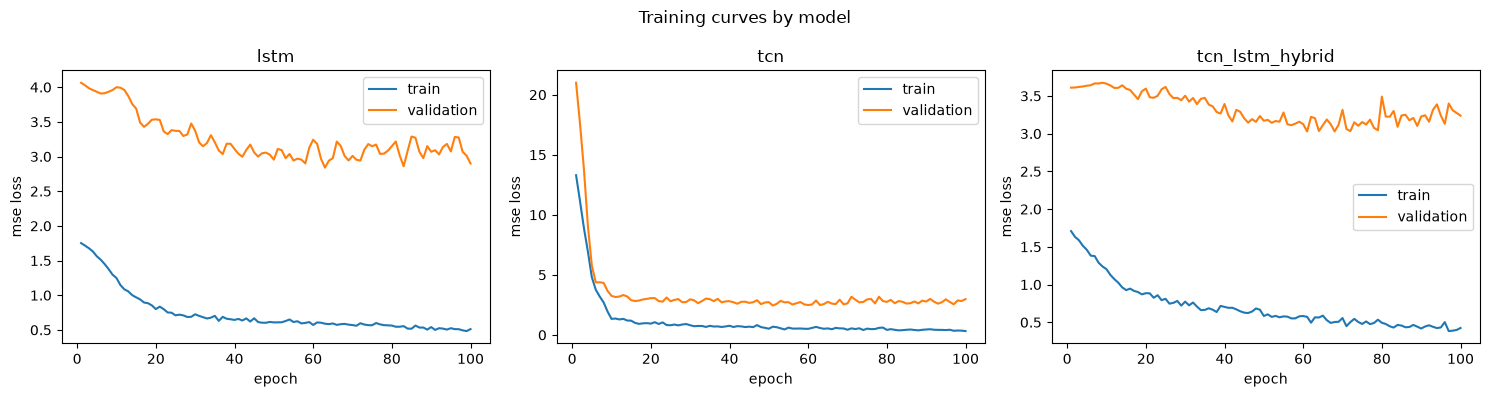

In [13]:
curves_path = Path("../results/training_curves.csv")
curves_df = pd.read_csv(curves_path)

sequence_models = ["lstm", "tcn", "tcn_lstm_hybrid"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model_name in zip(axes, sequence_models):
    model_curves = curves_df[curves_df["model_name"] == model_name]
    ax.plot(model_curves["epoch"], model_curves["train_loss"], label="train")
    ax.plot(model_curves["epoch"], model_curves["val_loss"], label="validation")
    ax.set_xlabel("epoch")
    ax.set_ylabel("mse loss")
    ax.set_title(model_name)
    ax.legend()

fig.suptitle("Training curves by model")
fig.tight_layout()
fig.savefig(figures_dir / "training_curves.png", dpi=600)
plt.show()

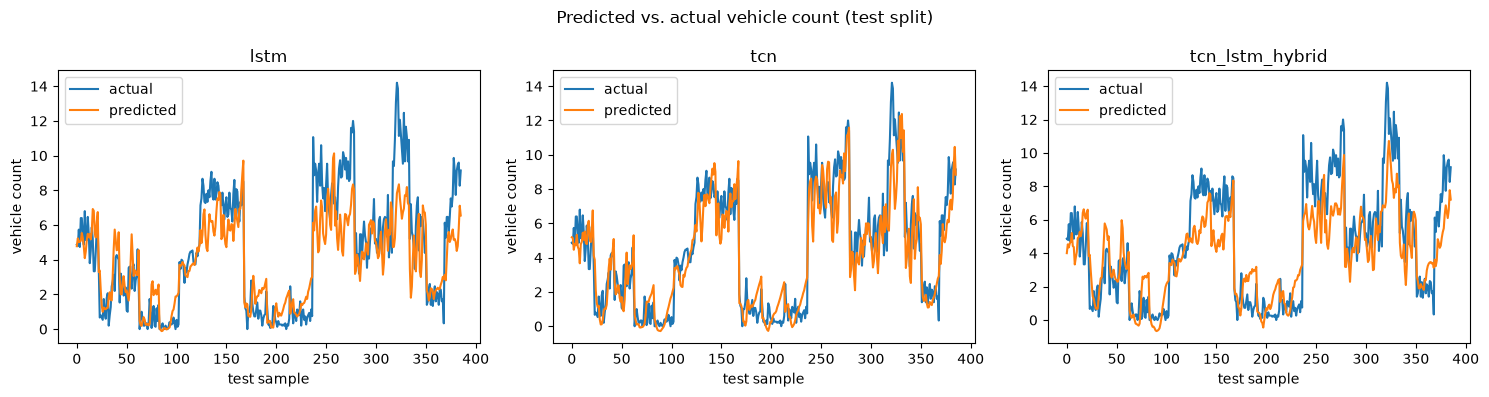

In [14]:
predictions_path = Path("../results/predictions.csv")
predictions_df = pd.read_csv(predictions_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model_name in zip(axes, sequence_models):
    model_preds = predictions_df[predictions_df["model_name"] == model_name]
    ax.plot(model_preds["actual"].values, label="actual")
    ax.plot(model_preds["predicted"].values, label="predicted")
    ax.set_xlabel("test sample")
    ax.set_ylabel("vehicle count")
    ax.set_title(model_name)
    ax.legend()

fig.suptitle("Predicted vs. actual vehicle count (test split)")
fig.tight_layout()
fig.savefig(figures_dir / "predicted_vs_actual.png", dpi=600)
plt.show()